## Importing Modules

In [226]:
import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for plotting
import matplotlib.cm as cm # for color maps in plots
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS # for converting text to TF-IDF features and for stop words
from sklearn.decomposition import TruncatedSVD, PCA # for dimensionality reduction
from sklearn.preprocessing import normalize # for normalizing data
from sklearn.metrics.pairwise import cosine_similarity # for calculating cosine similarity
from matplotlib.patches import Patch # for creating custom legend in plots

## Loading the preprocessed data

In [227]:
# We will load preprocessed data from the pickle file created in preprocessing.py
df = pd.read_pickle("../data_preprocessed.pkl")

# Just checking for missing values
df['cleaned_abstract'] = df['cleaned_abstract'].fillna('')
df['abstract'] = df['abstract'].fillna('')

print(f"Loaded preprocessed data with {len(df)} papers.") # printing the number of papers in the preprocessed DataFrame to confirm it loaded correctly
print(f"Periods : {df['period'].value_counts().sort_index()}") # printing the count of papers in each period to see the distribution of papers across different time periods
print(f"Years : {df['year'].min()} to {df['year'].max()}") # printing the range of years in the dataset to confirm it covers the expected time span

Loaded preprocessed data with 27121 papers.
Periods : period
2007-2011     1268
2012-2016     5542
2017-2021    20311
Name: count, dtype: int64
Years : 2007 to 2021


## Creating some helper functions, for easier integration

In [228]:
# This is a generic function which will be used to plot the projections for both TF-IDF PCA and SBERT PCA
# Here, key_event_positions is a dictionary of a syntax like {year: (lx, ly)} where lx and ly are the absolute label coordinates.
def plot_projection(ax, df_with_pcs, pc1_col, pc2_col, title, svd_or_pca = None, key_event_positions = None):
    # First, I will compute the centroids for each year, which will tell us average position of all papers in that year
    centroids = df_with_pcs.groupby('year')[[pc1_col, pc2_col]].mean().sort_index()
    years = centroids.index.tolist() 
    xs = centroids[pc1_col].tolist()
    ys = centroids[pc2_col].tolist()

    colors = cm.viridis(np.linspace(0, 1, len(years))) # This is a color gradient in which dark purple means old and yellow means new.

    # Now I will draw the line and dot for each year pair
    for i in range(len(years)-1):
        ax.plot([xs[i], xs[i+1]], [ys[i], ys[i+1]], color = colors[i], linewidth = 2, zorder = 1)
        ax.scatter(xs[i], ys[i], color = colors[i], s = 60, zorder = 2)
    ax.scatter(xs[-1], ys[-1], color = colors[-1], s = 60, zorder = 2) # for the last year

    # Here, I will set the labels near each dot
    for year, x, y in zip(years, xs, ys):
        ax.annotate(str(year), (x, y), textcoords="offset points", xytext=(5,5), fontsize=7)
    
    # Now the key events will be annotated with arrows
    if key_event_positions:
        for year, (label, (lx, ly)) in key_event_positions.items():
            if year in centroids.index:
                x, y = centroids.loc[year, [pc1_col, pc2_col]]
                ax.annotate(label, xy = (x, y), xytext = (lx, ly), fontsize = 8, color = 'red',
                            arrowprops = dict(arrowstyle = '->', color = 'red', lw = 1.5),
                            bbox = dict(boxstyle = 'round, pad = 0.2', fc = 'white', alpha = 0.8))
    
    # Finally, I will set the labels and title
    ax.set_title(title, fontsize = 11)
    if svd_or_pca is not None:
        ax.set_xlabel(f'PC1 ({svd_or_pca.explained_variance_ratio_[0]:.1%} variance)')
        ax.set_ylabel(f'PC2 ({svd_or_pca.explained_variance_ratio_[1]:.1%} variance)')
    else:
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
    
    # Adding the colorbar
    sm = plt.cm.ScalarMappable(cmap = cm.viridis, norm = plt.Normalize(vmin = min(years), vmax = max(years)))
    plt.colorbar(sm, ax = ax, label = 'Year')
    return centroids

# Now, I will create a function to calculate the cosine distance between centroids.
# Greater distance will mean, more shift in research that year.
def calculate_cosine_distances(centroids, pc1_col, pc2_col):
    years = centroids.index.tolist()
    distances = []

    for i in range(len(years)-1):
        v1 = centroids.loc[years[i], [pc1_col, pc2_col]].values.reshape(1, -1)
        v2 = centroids.loc[years[i+1], [pc1_col, pc2_col]].values.reshape(1, -1)
        sim = cosine_similarity(v1, v2)[0][0]
        distances.append({'transition': f"{years[i]} to {years[i+1]}", 'cosine_distance': round(1 - sim, 4)})
    return pd.DataFrame(distances)

## Building the TF-IDF matrices

In [229]:
# First, I will get the cleaned abstracts as a list, so that I can feed it into the TF-IDF vectorizer
abstracts = df['cleaned_abstract'].tolist() 

# My TF-IDF vectorizer will include unigrams and bigrams. I will remove the standard English stopwords.
vectorizer_rohan = TfidfVectorizer(max_features = 5000, ngram_range = (1, 2), stop_words = 'english')
X_tfidf_rohan = vectorizer_rohan.fit_transform(abstracts) # This is the sparse matrix of my TF-IDF features for all the papers
print(f'My TF-IDF: {X_tfidf_rohan.shape} (unigrams and bigrams, with standard stopwords)')

# Now, I will use my teammate's vectorizer, with custom academic boilerplate filter. It will use only bigrams.
academic_boilerplate = {
    'paper', 'propose', 'proposed', 'approach', 'method', 'methods',
    'results', 'experimental', 'experiment', 'show', 'shows',
    'using', 'based', 'performance', 'task', 'state', 'art'
}
combined_stopwords = list(ENGLISH_STOP_WORDS.union(academic_boilerplate))

# His vectorizer has some tuned parameters, which I will use as is.
vectorizer_chen = TfidfVectorizer(max_features = 5000, ngram_range = (2, 2), stop_words = combined_stopwords, max_df = 0.9, min_df = 5)
X_tfidf_chen = vectorizer_chen.fit_transform(abstracts) # This is the sparse matrix of Chen's TF-IDF features for all the papers
print(f'Chen\'s TF-IDF: {X_tfidf_chen.shape} (only bigrams, with custom stopwords)')

My TF-IDF: (27121, 5000) (unigrams and bigrams, with standard stopwords)
Chen's TF-IDF: (27121, 5000) (only bigrams, with custom stopwords)


## Applying TruncatedSVD to TF-IDF matrices

In [230]:
# Here, I will use TruncatedSVD instead of PCA because TF-IDF matrices are sparse and PCA does not work well with sparse data

# Firstly, I will reduce my TF-IDF matrix to 50 dimensions, to preserve information
svd_rohan_50 = TruncatedSVD(n_components = 50, random_state = 42)
svd_rohan_50.fit(X_tfidf_rohan)
print(f'My TF-IDF matrix reduced from 5000 to 50 dimensions with : {svd_rohan_50.explained_variance_ratio_.sum():.2%} variance retained')

# Now, I will reduce it to 2 dimensions for plotting
svd_rohan_2 = TruncatedSVD(n_components = 2, random_state = 42)
X_2d_rohan = svd_rohan_2.fit_transform(X_tfidf_rohan)
df['tfidf_rohan_pc1'] = X_2d_rohan[:, 0]
df['tfidf_rohan_pc2'] = X_2d_rohan[:, 1]
print(f'My TF-IDF matrix reduced from 5000 to 2 dimensions with: {svd_rohan_2.explained_variance_ratio_.sum():.2%} variance retained')

# Now, I will do the same for Chen's TF-IDF matrix.
svd_chen_50 = TruncatedSVD(n_components = 50, random_state = 42)
svd_chen_50.fit(X_tfidf_chen)
print(f'Chen\'s TF-IDF matrix reduced from 5000 to 50 dimensions with : {svd_chen_50.explained_variance_ratio_.sum():.2%} variance retained')

svd_chen_2 = TruncatedSVD(n_components = 2, random_state = 42)
X_2d_chen = svd_chen_2.fit_transform(X_tfidf_chen)
df['tfidf_chen_pc1'] = X_2d_chen[:, 0]
df['tfidf_chen_pc2'] = X_2d_chen[:, 1]
print(f'Chen\'s TF-IDF matrix reduced from 5000 to 2 dimensions with: {svd_chen_2.explained_variance_ratio_.sum():.2%} variance retained')

My TF-IDF matrix reduced from 5000 to 50 dimensions with : 12.02% variance retained
My TF-IDF matrix reduced from 5000 to 2 dimensions with: 0.99% variance retained
Chen's TF-IDF matrix reduced from 5000 to 50 dimensions with : 9.27% variance retained
Chen's TF-IDF matrix reduced from 5000 to 2 dimensions with: 0.73% variance retained


## Plotting both the TF-IDF side by side

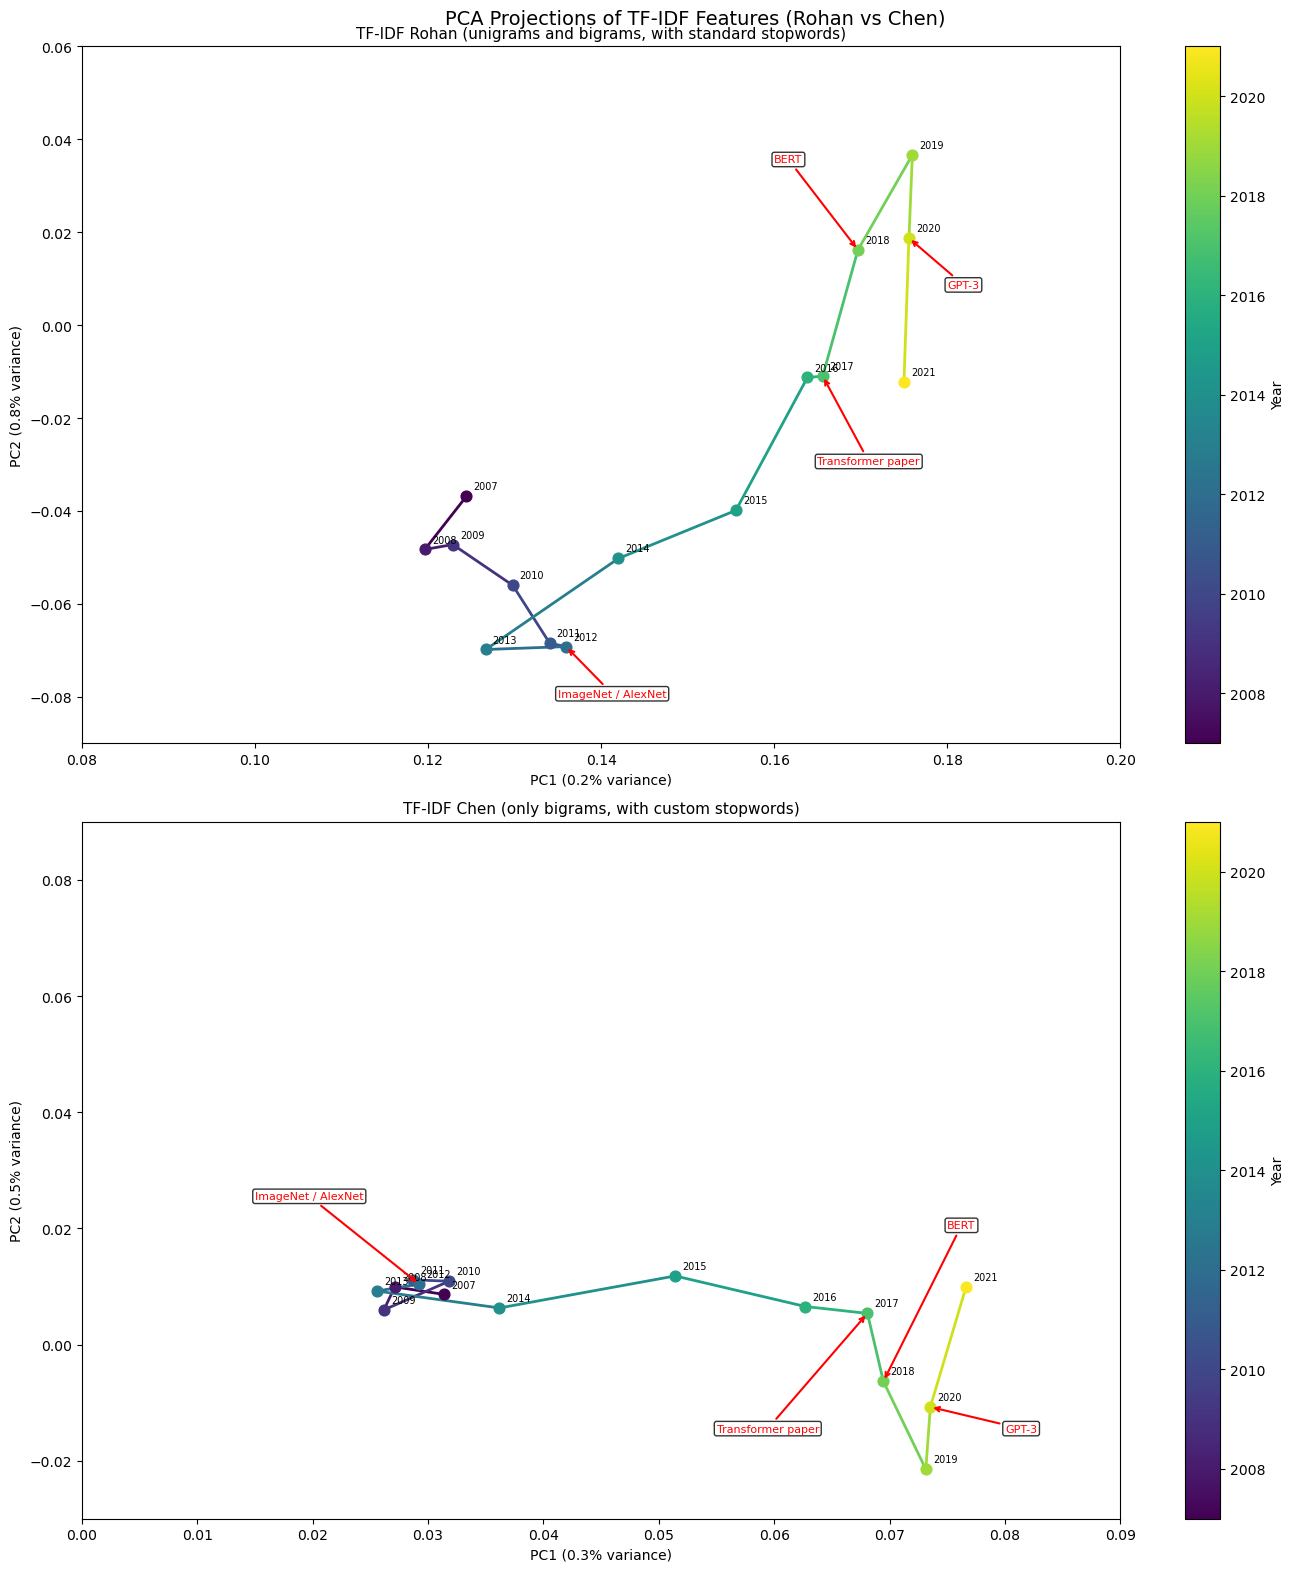

In [231]:
# I manually chose the label positions for the key events
tfidf_rohan_events = {
    2012: ('ImageNet / AlexNet', (0.135, -0.080)),
    2017: ('Transformer paper', (0.165, -0.030)),
    2018: ('BERT', (0.160, 0.035)),
    2020: ('GPT-3', (0.180, 0.008)),
}
tfidf_chen_events = {
    2012: ('ImageNet / AlexNet', (0.015, 0.025)),
    2017: ('Transformer paper', (0.055, -0.015)),
    2018: ('BERT', (0.075, 0.020)),
    2020: ('GPT-3', (0.080, -0.015)),
}
fig, axes = plt.subplots(2, 1, figsize = (14, 16))

centroids_tfidf_rohan = plot_projection(axes[0], df, 'tfidf_rohan_pc1', 'tfidf_rohan_pc2', svd_or_pca = svd_rohan_2,
                                        title = 'TF-IDF Rohan (unigrams and bigrams, with standard stopwords)', key_event_positions = tfidf_rohan_events)

centroids_tfidf_chen = plot_projection(axes[1], df, 'tfidf_chen_pc1', 'tfidf_chen_pc2', svd_or_pca = svd_chen_2,
                                        title = 'TF-IDF Chen (only bigrams, with custom stopwords)', key_event_positions = tfidf_chen_events)

# There was some empty space in the plots, so I manually set the limits, to visualise properly.
axes[0].set_xlim(0.08, 0.20)
axes[0].set_ylim(-0.09, 0.06)
axes[1].set_xlim(0.00, 0.09)
axes[1].set_ylim(-0.03, 0.09)

plt.suptitle('PCA Projections of TF-IDF Features (Rohan vs Chen)', fontsize = 14)
plt.tight_layout()
plt.savefig('../figures/pca_tfidf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Loading Nithya's SBERT embeddings

In [ ]:
embeddings_dict = {}

for name, filepath in [
    ('MiniLM', '../Nithya/model_embeddings/embeddings_nithya.npy'),
    ('Specter', '../Nithya/model_embeddings/specter_model_embeddings_nithya.npy'),
    ('MPNet', '../Nithya/model_embeddings/mpnet_model_embeddings_nithya.npy')
]:
    emb = np.load(filepath)
    # Now there is a critical check which I have to do. The order of papers in the embeddings should be the same as the order of 
    # papers in the DataFrame, otherwise PCA will map wrong paper and year.
    assert len(emb) == len(df), f"Length mismatch for {name} embeddings where embedding have{len(emb)} while dataframe has {len(df)}"
    embeddings_dict[name] = emb
    print(f"Loaded {name} embeddings with shape, {emb.shape}")

print(f'\nLoaded {len(embeddings_dict)} SBERT models, which are {list(embeddings_dict.keys())}')

Loaded MiniLM embeddings with shape, (27121, 384)
Loaded Specter embeddings with shape, (27121, 768)
Loaded MPNet embeddings with shape, (27121, 768)

Loaded 3 SBERT models, which are ['MiniLM', 'Specter', 'MPNet']


## Applying PCA to SBERT embeddings

In [233]:
# Here, I will use PCA instead of TruncatedSVD because SBERT embeddings are dense and PCA works well with dense data.
pca_models = {}

for name, emb in embeddings_dict.items():
    pca = PCA(n_components = 2, random_state = 42) # Reducing to 2 dimensions for better plotting
    X_2d = pca.fit_transform(emb)

    # I will add these 2D coordinates to my dataframe. Mainly because I will need them later for plotting and calculating cosine distances.
    col_pc1 = f'sbert_{name.lower()}_pc1'
    col_pc2 = f'sbert_{name.lower()}_pc2'
    df[col_pc1] = X_2d[:, 0]
    df[col_pc2] = X_2d[:, 1]

    pca_models[name] = pca
    print(f'{name} SBERT embeddings with {emb.shape[1]} dimensions reduced to 2 dimensions while retaining {pca.explained_variance_ratio_.sum():.2%} variance')


MiniLM SBERT embeddings with 384 dimensions reduced to 2 dimensions while retaining 13.81% variance
Specter SBERT embeddings with 768 dimensions reduced to 2 dimensions while retaining 18.32% variance
MPNet SBERT embeddings with 768 dimensions reduced to 2 dimensions while retaining 14.67% variance


In [234]:
print("From the above results, we can see that the SBERT embeddings have retained a much higher variance, when reduced to 2 dimensions as \ncompared to the TF-IDF features. This shows us that the SBERT embeddings capture more meaningful information in fewer dimensions. \nActually, it is expected because the embeddings are dense and semantic.")

From the above results, we can see that the SBERT embeddings have retained a much higher variance, when reduced to 2 dimensions as 
compared to the TF-IDF features. This shows us that the SBERT embeddings capture more meaningful information in fewer dimensions. 
Actually, it is expected because the embeddings are dense and semantic.


## Plotting the SBERT trajectories

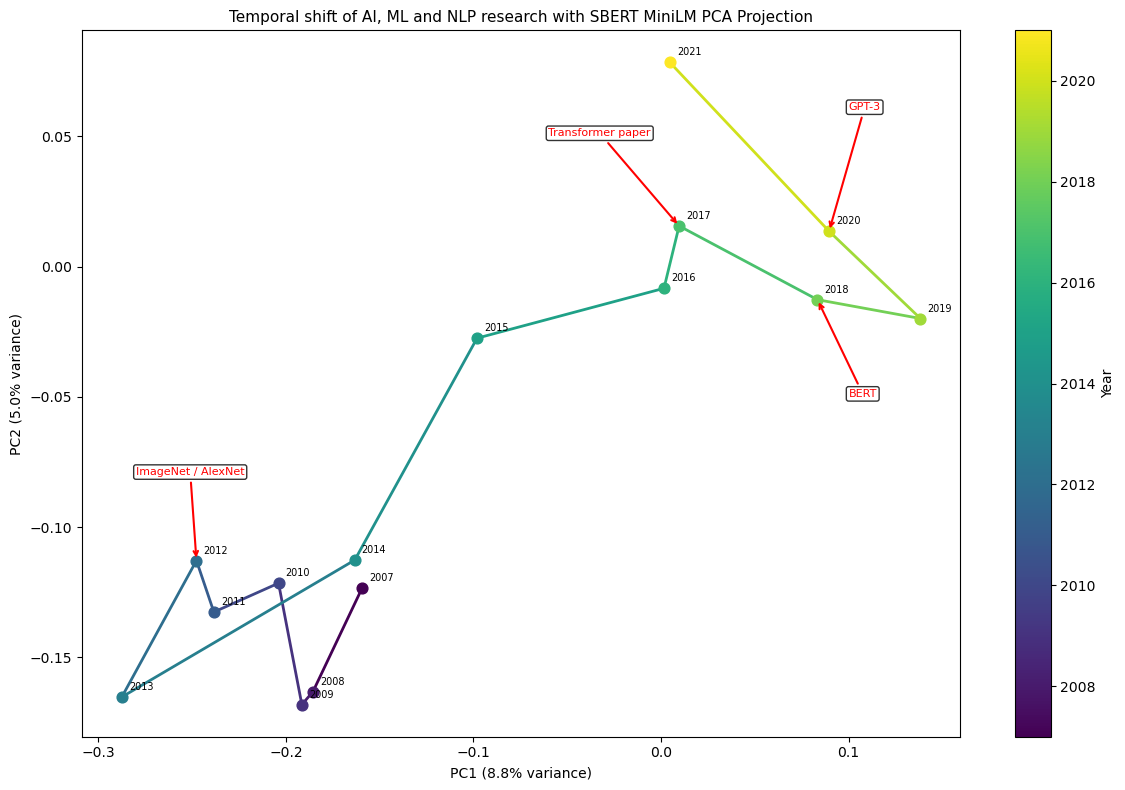

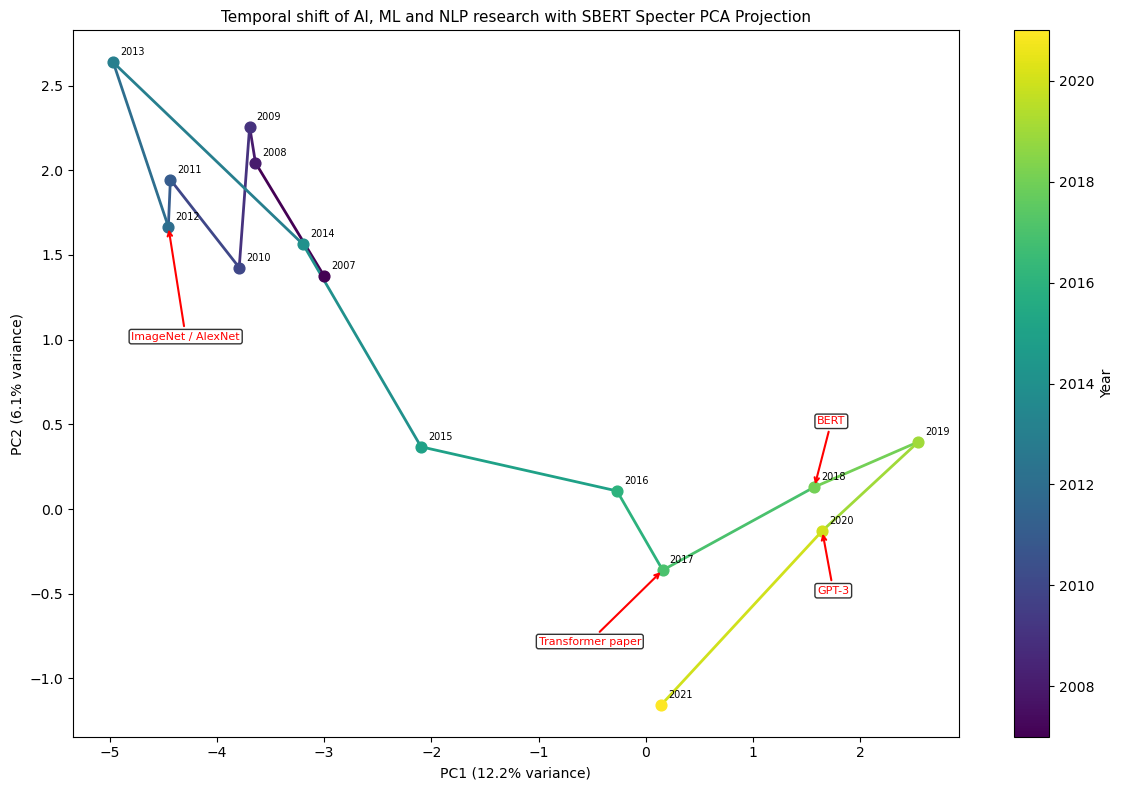

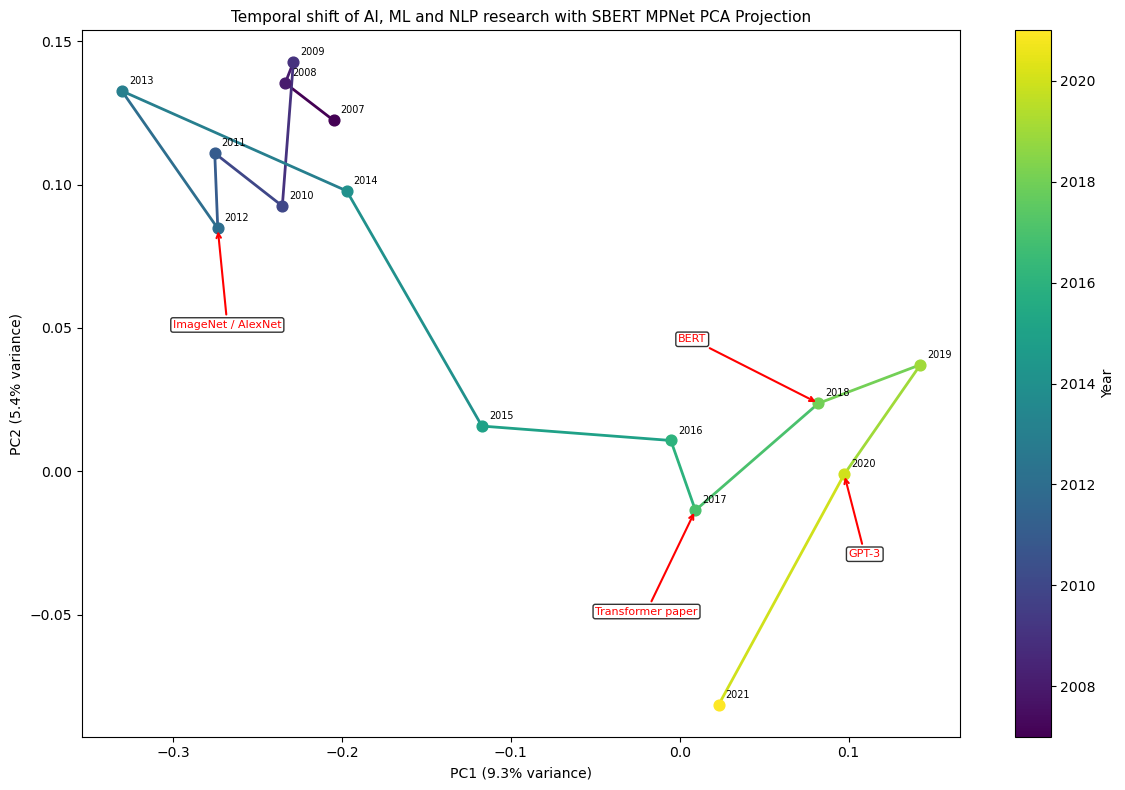

In [235]:
# Here, I will manually choose the label positions for the key events for each SBERT model.
sbert_events = {
    'MiniLM': {
        2012: ('ImageNet / AlexNet',(-0.28, -0.08)),
        2017: ('Transformer paper', (-0.06, 0.05)),
        2018: ('BERT', (0.10, -0.05)),
        2020: ('GPT-3', (0.10, 0.06)),
    },
    'Specter': {
        2012: ('ImageNet / AlexNet',(-4.80, 1.0)),
        2017: ('Transformer paper', (-1, -0.80)),
        2018: ('BERT', (1.6, 0.5)),
        2020: ('GPT-3', (1.6, -0.5)),
    },
    'MPNet': {
        2012: ('ImageNet / AlexNet',(-0.30, 0.05)),
        2017: ('Transformer paper', (-0.05, -0.05)),
        2018: ('BERT', (-0.001, 0.045)),
        2020: ('GPT-3', (0.10, -0.03)),
    }
}

sbert_centroids = {}

for name in embeddings_dict.keys():
    col_pc1 = f'sbert_{name.lower()}_pc1'
    col_pc2 = f'sbert_{name.lower()}_pc2'
    
    fig, ax = plt.subplots(figsize = (12, 8))
    centroids = plot_projection(ax, df, col_pc1, col_pc2, svd_or_pca = pca_models[name], key_event_positions = sbert_events.get(name, None),
                                title = f'Temporal shift of AI, ML and NLP research with SBERT {name} PCA Projection')
    sbert_centroids[name] = (centroids, col_pc1, col_pc2) # I will need these centroids later to calculate the cosine distances

    plt.tight_layout()
    fname = f'../figures/pca_sbert_{name.lower()}_trajectory.png'
    plt.savefig(fname, dpi=150)
    plt.show()

# Now, side-by-side comparison of all representations

I have a total of 5 representations to compare, which are as following: 
['TF-IDF Rohan (unigrams and bigrams, with standard stopwords)', 'TF-IDF Chen (only bigrams, with custom stopwords)', 'SBERT MiniLM', 'SBERT Specter', 'SBERT MPNet']


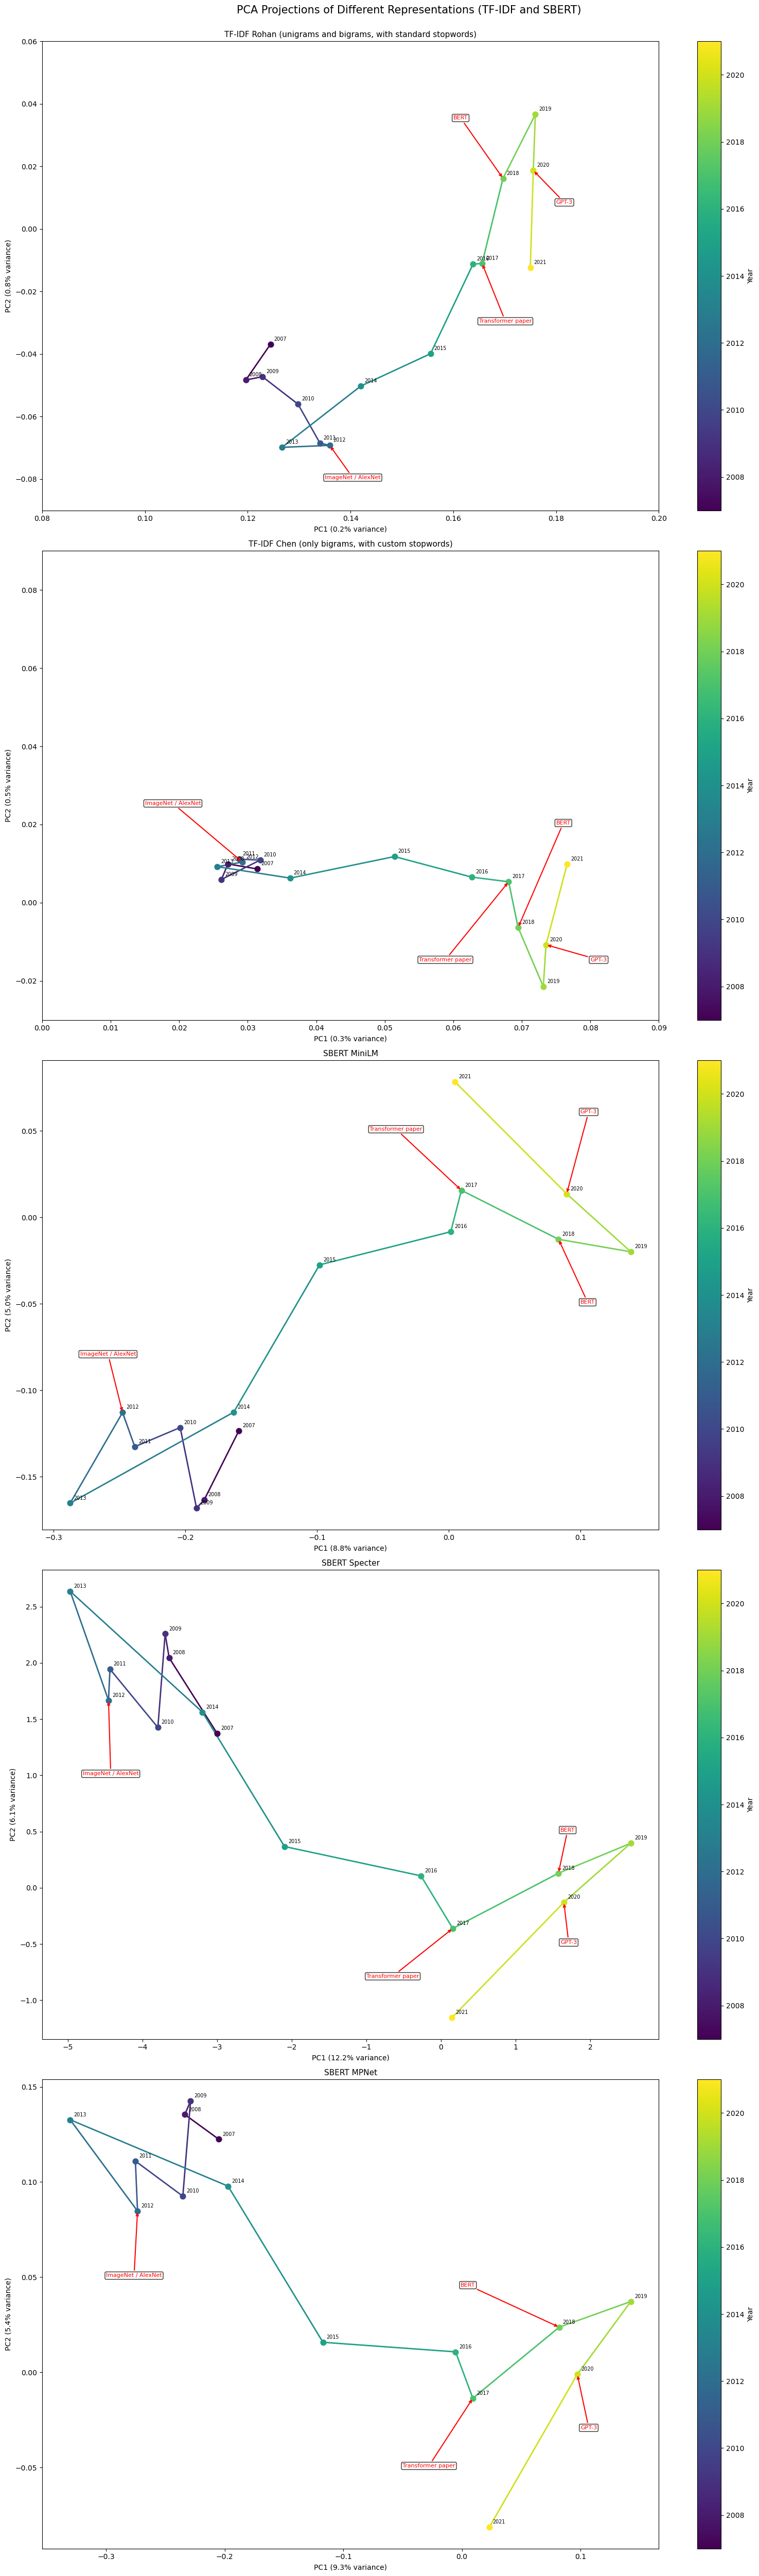

In [236]:
# Here, I am adding the TF-IDF centroids to the representations list, to use them later.
representations = [('TF-IDF Rohan (unigrams and bigrams, with standard stopwords)', 'tfidf_rohan_pc1', 'tfidf_rohan_pc2', svd_rohan_2, tfidf_rohan_events),
                   ('TF-IDF Chen (only bigrams, with custom stopwords)', 'tfidf_chen_pc1', 'tfidf_chen_pc2', svd_chen_2, tfidf_chen_events)]

# Adding the SBERT centroids to the same representations list, to use them later.
for name, (centroids, col_pc1, col_pc2) in sbert_centroids.items():
    representations.append((f'SBERT {name}', col_pc1, col_pc2, pca_models[name], sbert_events.get(name, None)))

n = len(representations)
print(f"I have a total of {n} representations to compare, which are as following: \n{[rep[0] for rep in representations]}")

fig, axes = plt.subplots(n, 1, figsize = (16, 10 * n))
if n == 1:
    axes = [axes] # Just to make it iterable

all_centroids = {} # I will store the centroids for all representations here, and will use them later for calculating cosine distances.
for ax, (title, pc1, pc2, model, events) in zip(axes, representations):
    centroids = plot_projection(ax, df, pc1, pc2, title = title, svd_or_pca = model, key_event_positions = events)
    all_centroids[title] = (centroids, pc1, pc2)
    # Manually setting the limits for better plotting in TF-IDF plots
    if 'Rohan' in title:
        ax.set_xlim(0.08, 0.20)
        ax.set_ylim(-0.09, 0.06)
    elif 'Chen' in title:
        ax.set_xlim(0.00, 0.09)
        ax.set_ylim(-0.03, 0.09)

plt.suptitle('PCA Projections of Different Representations (TF-IDF and SBERT)', fontsize = 15, y=1.00)
plt.tight_layout()
plt.savefig('../figures/pca_all_representations_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Plotting the cosine distance for all the representations

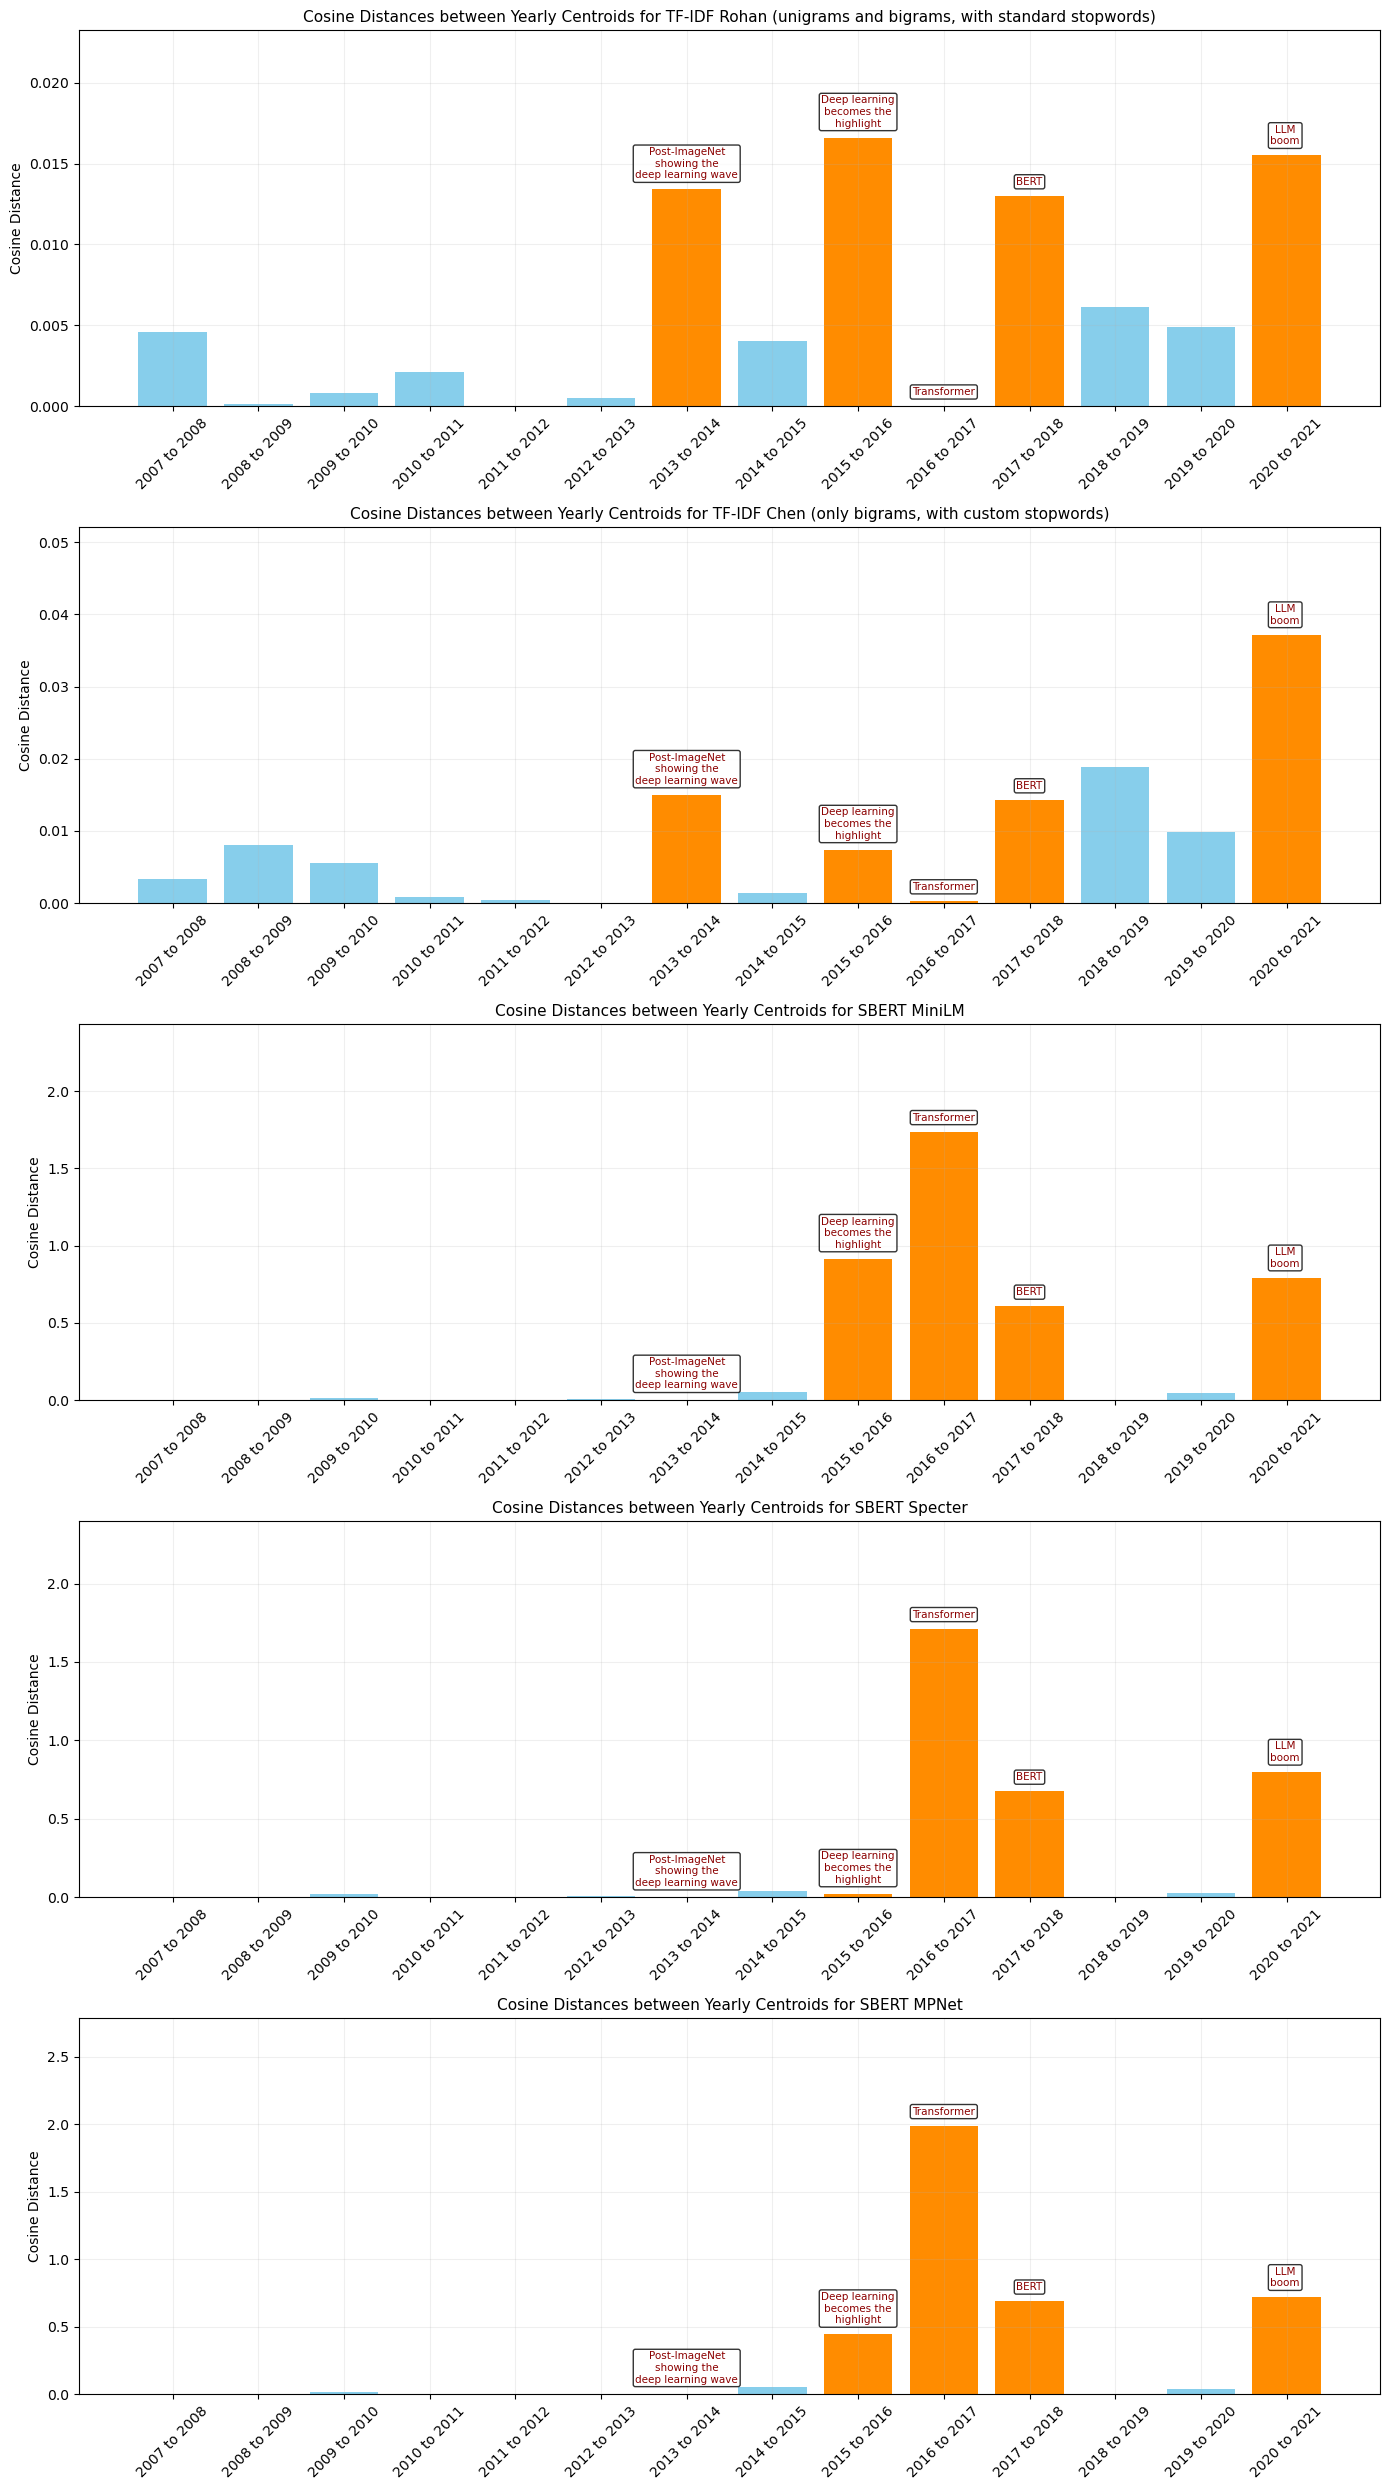

In [237]:
# Few key transitions in AIML research, which I will show on the plots.
key_transitions = {
    '2013 to 2014': ('Post-ImageNet\nshowing the\ndeep learning wave', (0, 8)),
    '2015 to 2016': ('Deep learning\nbecomes the\nhighlight', (0, 8)),
    '2016 to 2017': ('Transformer', (0, 8)),
    '2017 to 2018': ('BERT', (0, 8)),
    '2020 to 2021': ('LLM\nboom', (-1, 8)),
}

all_distances = {}
# Now, this will create a dataframe. It will have two columns, transition and cosine_distance, for each representation
for title, (centroids, pc1_col, pc2_col) in all_centroids.items():
    all_distances[title] = calculate_cosine_distances(centroids, pc1_col, pc2_col)

fig, axes = plt.subplots(len(all_distances), 1, figsize = (14, 5 * len(all_distances)))
if len(all_distances) == 1:
    axes = [axes] # Just to make it iterable

for ax, (title, distances_df) in zip(axes, all_distances.items()):
    colors = ['darkorange' if t in key_transitions else 'skyblue' for t in distances_df['transition']] # Highlighting the key transitions with a different color
    ax.bar(distances_df['transition'], distances_df['cosine_distance'], color = colors) 
    ax.set_ylim(0, distances_df['cosine_distance'].max() * 1.4) # Adding some space on top for the labels

    for _, row in distances_df.iterrows():
        if row['transition'] in key_transitions:
            label, offset = key_transitions[row['transition']] # Getting the label and offset for the key transition
            ax.annotate(label, xy = (row['transition'], row['cosine_distance']), xytext = offset, textcoords = 'offset points', ha = 'center',
                        fontsize = 7.5, color = 'darkred', bbox = dict(boxstyle = 'round, pad = 0.2', fc = 'white', alpha = 0.8))
    
    ax.set_title(f'Cosine Distances between Yearly Centroids for {title}', fontsize = 11)
    ax.tick_params(axis = 'x', rotation = 45)
    ax.set_ylabel('Cosine Distance')
    ax.grid(True, alpha = 0.2)

plt.tight_layout()
plt.savefig('../figures/cosine_distances_all_representations.png', dpi=150, bbox_inches='tight')
plt.show()

## A variance summary table for comparison

Explained Variance Summary for Different Representations:
                                              Representation  Input dimensions    PC1   PC2 Total Variance
TF-IDF Rohan (unigrams and bigrams, with standard stopwords)              5000  0.22% 0.77%          0.99%
           TF-IDF Chen (only bigrams, with custom stopwords)              5000  0.27% 0.46%          0.73%
                                                SBERT MiniLM               384  8.81% 5.00%         13.81%
                                               SBERT Specter               768 12.22% 6.10%         18.32%
                                                 SBERT MPNet               768  9.26% 5.41%         14.67%


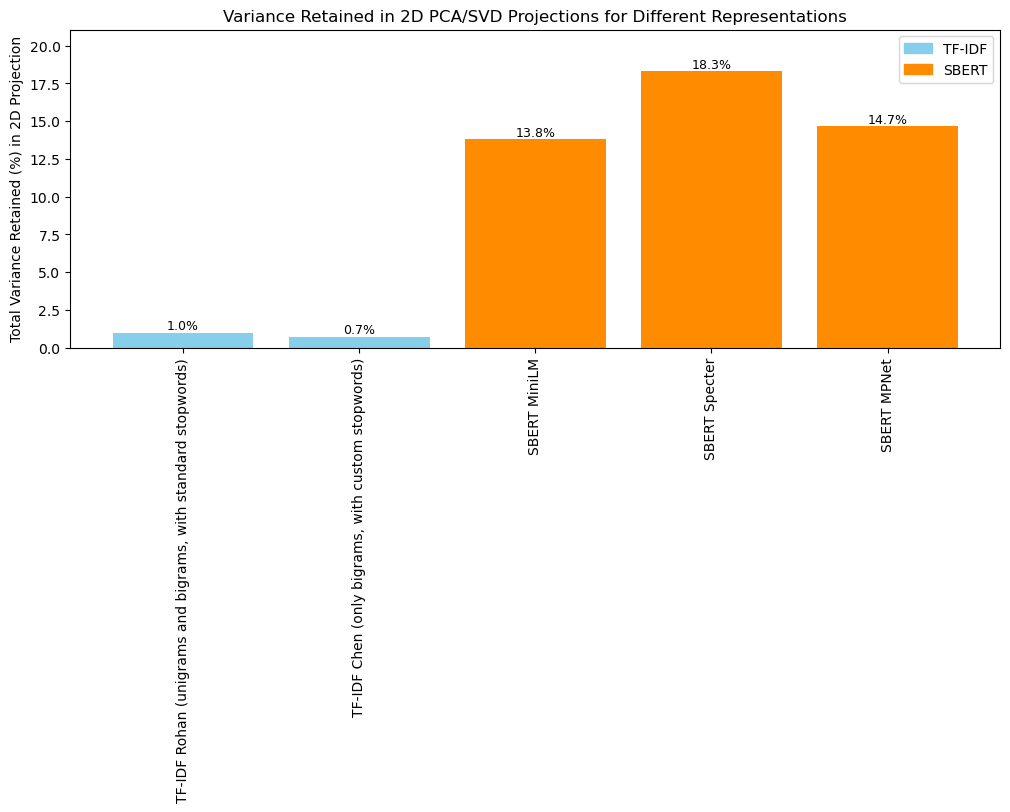


From the above results, we can see that the SBERT embeddings have retained a much higher variance, when reduced to 2 dimensions as 
compared to the TF-IDF features.


In [238]:
# Finally, I will create a summary table which will show the variance retained in the 2D projections. It will be for each representation.
summary_rows = [
    {
        'Representation': 'TF-IDF Rohan (unigrams and bigrams, with standard stopwords)',
        'Input dimensions': X_tfidf_rohan.shape[1],
        'PC1': f'{svd_rohan_2.explained_variance_ratio_[0]:.2%}',
        'PC2': f'{svd_rohan_2.explained_variance_ratio_[1]:.2%}',
        'Total Variance': f'{svd_rohan_2.explained_variance_ratio_.sum():.2%}',
    },
    {
        'Representation': 'TF-IDF Chen (only bigrams, with custom stopwords)',
        'Input dimensions': X_tfidf_chen.shape[1],
        'PC1': f'{svd_chen_2.explained_variance_ratio_[0]:.2%}',
        'PC2': f'{svd_chen_2.explained_variance_ratio_[1]:.2%}',
        'Total Variance': f'{svd_chen_2.explained_variance_ratio_.sum():.2%}',
    }
]

for name, pca in pca_models.items():
    emb = embeddings_dict[name]
    summary_rows.append({
        'Representation': f'SBERT {name}',
        'Input dimensions': emb.shape[1],
        'PC1': f'{pca.explained_variance_ratio_[0]:.2%}',
        'PC2': f'{pca.explained_variance_ratio_[1]:.2%}',
        'Total Variance': f'{pca.explained_variance_ratio_.sum():.2%}',
    })
# Here, I will be creating a dataframe from the summary rows.
summary_df = pd.DataFrame(summary_rows)
print("Explained Variance Summary for Different Representations:")
print(summary_df.to_string(index = False))

# Now, I will create a bar plot, in order to visualise the variance comparison between different representations.
totals = [float(row['Total Variance'].strip('%')) for row in summary_rows]
names = [row['Representation'] for row in summary_rows]
colors = ['skyblue', 'skyblue'] + ['darkorange'] * len(pca_models) # Highlighting the SBERT models with a different color

fig, ax = plt.subplots(figsize = (12, 6))
bars = ax.bar(names, totals, color = colors)
ax.set_ylabel('Total Variance Retained (%) in 2D Projection')
ax.set_title('Variance Retained in 2D PCA/SVD Projections for Different Representations')
ax.tick_params(axis = 'x', rotation = 90)
for i, val in enumerate(totals):
    ax.text(i, val + 0.2, f'{val:.1f}%', ha = 'center', fontsize = 9)
legend = [Patch(color = 'skyblue', label = 'TF-IDF'), Patch(color = 'darkorange', label = 'SBERT')]
ax.legend(handles = legend)
ax.set_ylim(0, max(totals) * 1.15) # Adding some space on top for the labels
plt.subplots_adjust(bottom = 0.35) # Adjusting the bottom to prevent label cutoff
plt.savefig('../figures/variance_retained_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFrom the above results, we can see that the SBERT embeddings have retained a much higher variance, when reduced to 2 dimensions as \ncompared to the TF-IDF features.")

In [239]:
# Computing total cumulative drift for each representation.
# I will do this, by adding all the cosine distances for each representation. Higher sum will mean, more shift in research that year.
for title, distances_df in all_distances.items():
    total_drift = distances_df['cosine_distance'].sum()
    max_year = distances_df.loc[distances_df['cosine_distance'].idxmax(), 'transition'] # Getting the year pair with maximum drift
    max_value = distances_df['cosine_distance'].max() # Getting the maximum drift value
    print(f"{title} has a total cumulative drift of {total_drift:.4f}, with the maximum drift of {max_value:.4f} occurring during the transition of {max_year}")

TF-IDF Rohan (unigrams and bigrams, with standard stopwords) has a total cumulative drift of 0.0816, with the maximum drift of 0.0166 occurring during the transition of 2015 to 2016
TF-IDF Chen (only bigrams, with custom stopwords) has a total cumulative drift of 0.1226, with the maximum drift of 0.0372 occurring during the transition of 2020 to 2021
SBERT MiniLM has a total cumulative drift of 4.1763, with the maximum drift of 1.7370 occurring during the transition of 2016 to 2017
SBERT Specter has a total cumulative drift of 3.3071, with the maximum drift of 1.7118 occurring during the transition of 2016 to 2017
SBERT MPNet has a total cumulative drift of 3.9547, with the maximum drift of 1.9901 occurring during the transition of 2016 to 2017


## Exporting PCA co-ordinates for the final integration

In [240]:
# Exporting 2D coordinates and centroids to CSV for the final integration
# First I will do my TF-IDF PCA coordinates
pd.DataFrame({
    'x': df['tfidf_rohan_pc1'],
    'y': df['tfidf_rohan_pc2'],
    'year': df['year'],
    'period': df['period'],
    'representation': 'TF-IDF Rohan'}).to_csv('../pca_tfidf_rohan_coordinates.csv', index = False)
# Then I will do CHen's TF-IDF PCA coordinates
pd.DataFrame({
    'x': df['tfidf_chen_pc1'],
    'y': df['tfidf_chen_pc2'],
    'year': df['year'],
    'period': df['period'],
    'representation': 'TF-IDF Chen'}).to_csv('../pca_tfidf_chen_coordinates.csv', index = False)
# Lastly, the SBERT PCA coordinates for each model
for name in embeddings_dict.keys():
    col_pc1 = f'sbert_{name.lower()}_pc1'
    col_pc2 = f'sbert_{name.lower()}_pc2'
    pd.DataFrame({
        'x': df[col_pc1],
        'y': df[col_pc2],
        'year': df['year'],
        'period': df['period'],
        'representation': f'SBERT {name}'}).to_csv(f'../pca_sbert_{name.lower()}_coordinates.csv', index = False)